In [16]:
# --- INSTALLATION ---
# python -m venv .venv
# .venv\Scripts\activate
# pip install ipykernel pandas seaborn matplotlib scipy

<h1>Setting Up</h1>

In [ ]:
# --- Import Libraries ---
import numpy as np

import pandas as pd
from pandas.api.types import is_numeric_dtype

import seaborn as sns

import matplotlib
import matplotlib.pyplot as plt
plt.style.use('ggplot')
from matplotlib.pyplot import figure

# embedd plots as static images
%matplotlib inline
# change sizings
matplotlib.rcParams['figure.figsize']=(12,8)

from scipy import stats
from scipy.stats import mannwhitneyu

# --- Changing Options ---
# showing full data
pd.set_option('display.max_rows', None)
pd.reset_option('display.max_rows')

pd.set_option('display.float_format', lambda x: f'{x:,.0f}')    # show full big numbers
np.set_printoptions(suppress=True, precision=10) # round small numbers

In [ ]:
# --- Import Data ---
df = pd.read_csv(r'C:\Users\THU THAO\Downloads\self studi\data analyst\data\4\movies.csv')
df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8,"927,000",Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,"19,000,000","46,998,772",Warner Bros.,146
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",6,"65,000",Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,"4,500,000","58,853,106",Columbia Pictures,104
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",9,"1,200,000",Irvin Kershner,Leigh Brackett,Mark Hamill,United States,"18,000,000","538,375,067",Lucasfilm,124
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",8,"221,000",Jim Abrahams,Jim Abrahams,Robert Hays,United States,"3,500,000","83,453,539",Paramount Pictures,88
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7,"108,000",Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,"6,000,000","39,846,344",Orion Pictures,98


<h1>Data Cleaning</h1>

In [ ]:
# ---Missing Data ---
# Show Missing Data
for col in df.columns:
    print('{} - {}%'.format(col, np.mean(df[col].isnull())* 100))
    print(df[col].isnull().value_counts(), '\n')

display(df[df.isnull().any(axis=1)].head())

# Handle Missing Data
# Drop Missings Data Columns
# df.dropna()

# Change all null numbers to 0
for col in df.columns:
    if is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(0)

name - 0.0%
name
False    7668
Name: count, dtype: int64 

rating - 1.004173187271779%
rating
False    7591
True       77
Name: count, dtype: int64 

genre - 0.0%
genre
False    7668
Name: count, dtype: int64 

year - 0.0%
year
False    7668
Name: count, dtype: int64 

released - 0.02608242044861763%
released
False    7666
True        2
Name: count, dtype: int64 

score - 0.03912363067292645%
score
False    7665
True        3
Name: count, dtype: int64 

votes - 0.03912363067292645%
votes
False    7665
True        3
Name: count, dtype: int64 

director - 0.0%
director
False    7668
Name: count, dtype: int64 

writer - 0.03912363067292645%
writer
False    7665
True        3
Name: count, dtype: int64 

star - 0.013041210224308816%
star
False    7667
True        1
Name: count, dtype: int64 

country - 0.03912363067292645%
country
False    7665
True        3
Name: count, dtype: int64 

budget - 28.31246739697444%
budget
False    5497
True     2171
Name: count, dtype: int64 

gross - 2.46478

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
16,Fame,R,Drama,1980,"May 16, 1980 (United States)",7,"21,000",Alan Parker,Christopher Gore,Eddie Barth,United States,NaN,"21,202,829",Metro-Goldwyn-Mayer (MGM),134
19,Stir Crazy,R,Comedy,1980,"December 12, 1980 (United States)",7,"26,000",Sidney Poitier,Bruce Jay Friedman,Gene Wilder,United States,NaN,"101,300,000",Columbia Pictures,111
24,Urban Cowboy,PG,Drama,1980,"June 6, 1980 (United States)",6,"14,000",James Bridges,Aaron Latham,John Travolta,United States,NaN,"46,918,287",Paramount Pictures,132
25,Altered States,R,Horror,1980,"December 25, 1980 (United States)",7,"33,000",Ken Russell,Paddy Chayefsky,William Hurt,United States,NaN,"19,853,892",Warner Bros.,102
26,Little Darlings,R,Comedy,1980,"March 21, 1980 (United States)",6,"5,100",Ron Maxwell,Kimi Peck,Tatum O'Neal,United States,NaN,"34,326,249",Stephen Friedman/Kings Road Productions,96


In [ ]:
# --- Data Types ---
display(df.dtypes)

# Change Data Types
for col in ['budget', 'gross', 'votes']:
    df[col] = df[col].astype('int64')

name            str
rating          str
genre           str
year          int64
released        str
score       float64
votes       float64
director        str
writer          str
star            str
country         str
budget      float64
gross       float64
company         str
runtime     float64
dtype: object

In [ ]:
# --- Dividing Data ---
# Etract Released Date, Year and Country Data
df['releasedDate'] = (pd.to_datetime(df['released']
                            .str.split(r' \(', n=1).str[0], format='mixed'))
df['yearCorrect'] = df['released'].str.split().str[2]
df['releasedCountry'] = df['released'].str.extract(r'\((.*)\)') # regex

In [ ]:
# --- Duplicates ---
# Drop Duplicates
(df.sort_values(by=['releasedDate'])['name']
    .drop_duplicates(keep='last')
    .sort_values(ascending=False))

4722                      Æon Flux
4761       xXx: State of the Union
7112    xXx: Return of Xander Cage
4083                           xXx
3503                      eXistenZ
                   ...            
6906           10 Cloverfield Lane
1099       *batteries not included
1013                'night, Mother
1006               'Round Midnight
6569                           '71
Name: name, Length: 7512, dtype: str

In [ ]:
# --- Sorting ---
df.sort_values(by=['gross'], inplace=False, ascending=False)

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,releasedDate,yearCorrect,releasedCountry
5445,Avatar,PG-13,Action,2009,"December 18, 2009 (United States)",8,1100000,James Cameron,James Cameron,Sam Worthington,United States,237000000,2847246203,Twentieth Century Fox,162,2009-12-18,2009,United States
7445,Avengers: Endgame,PG-13,Action,2019,"April 26, 2019 (United States)",8,903000,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,356000000,2797501328,Marvel Studios,181,2019-04-26,2019,United States
3045,Titanic,PG-13,Drama,1997,"December 19, 1997 (United States)",8,1100000,James Cameron,James Cameron,Leonardo DiCaprio,United States,200000000,2201647264,Twentieth Century Fox,194,1997-12-19,1997,United States
6663,Star Wars: Episode VII - The Force Awakens,PG-13,Action,2015,"December 18, 2015 (United States)",8,876000,J.J. Abrams,Lawrence Kasdan,Daisy Ridley,United States,245000000,2069521700,Lucasfilm,138,2015-12-18,2015,United States
7244,Avengers: Infinity War,PG-13,Action,2018,"April 27, 2018 (United States)",8,897000,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,321000000,2048359754,Marvel Studios,149,2018-04-27,2018,United States
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7663,More to Life,NaN,Drama,2020,"October 23, 2020 (United States)",3,18,Joseph Ebanks,Joseph Ebanks,Shannon Bond,United States,7000,0,NaN,90,2020-10-23,2020,United States
641,Blame It on the Night,PG-13,Comedy,1984,"November 2, 1984 (United States)",5,172,Gene Taft,Gene Taft,Nick Mancuso,United States,0,0,Delphi II Productions,85,1984-11-02,1984,United States
7658,Black Wall Street Burning,R,Drama,2020,"February 7, 2020 (United States)",7,35,Marcus Brown,Dekoven Riggins,Dan Belcher,United States,5000,0,Notis Studio,78,2020-02-07,2020,United States
671,Flesh+Blood,R,Adventure,1985,"August 30, 1985 (United States)",7,17000,Paul Verhoeven,Gerard Soeteman,Rutger Hauer,Netherlands,6500000,0,Riverside Pictures,126,1985-08-30,1985,United States


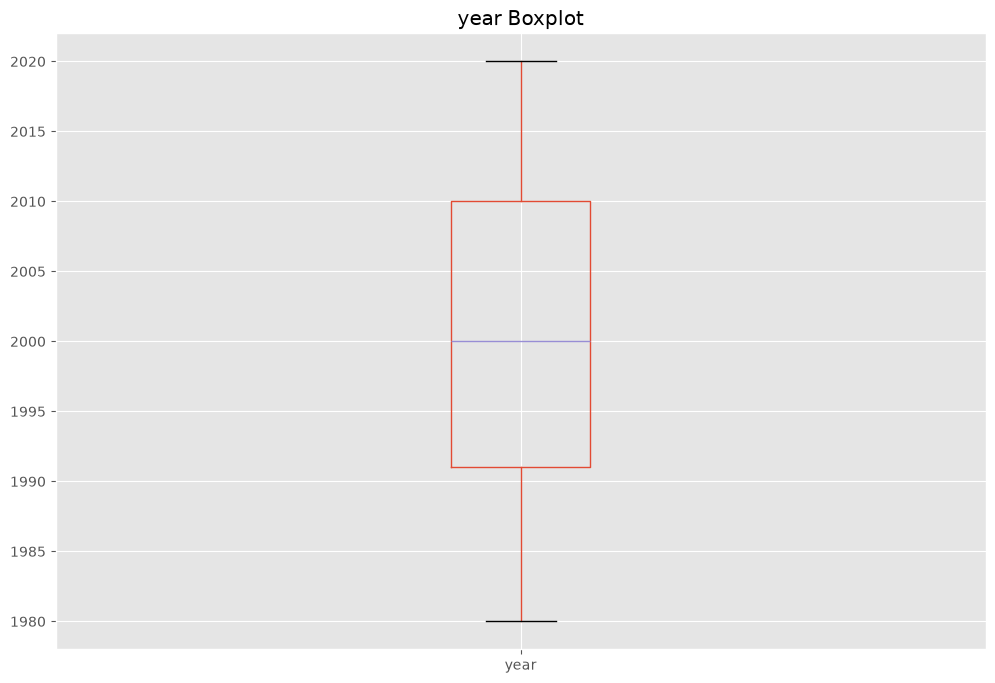

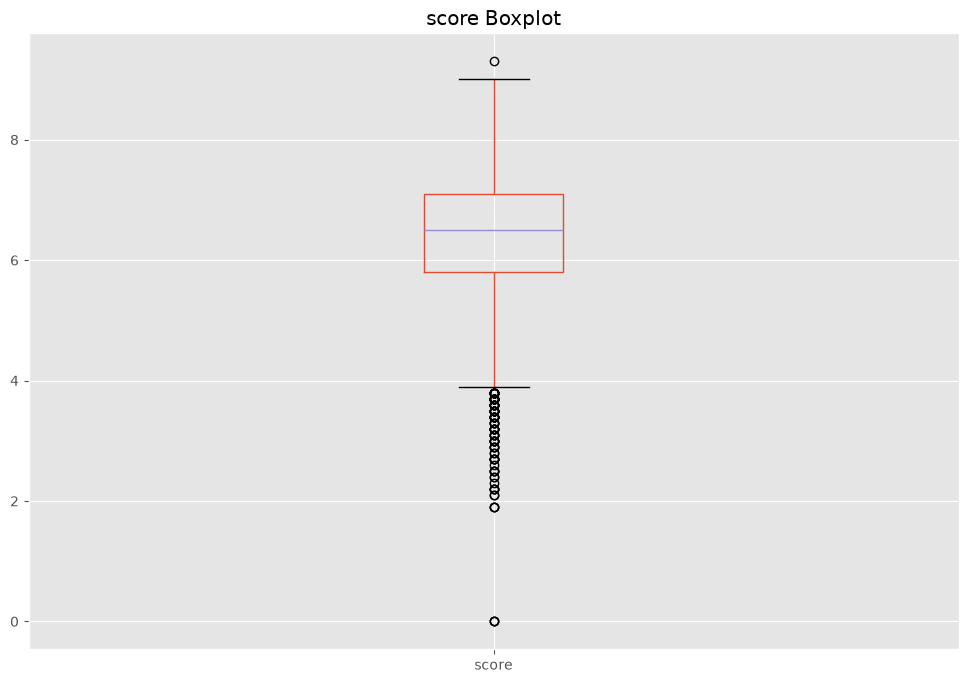

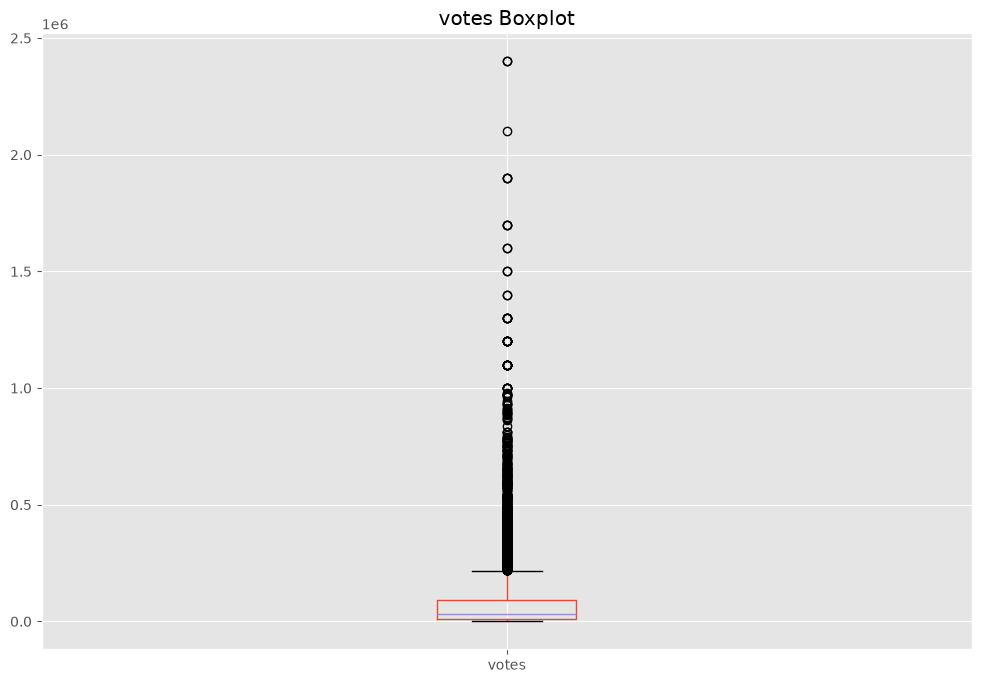

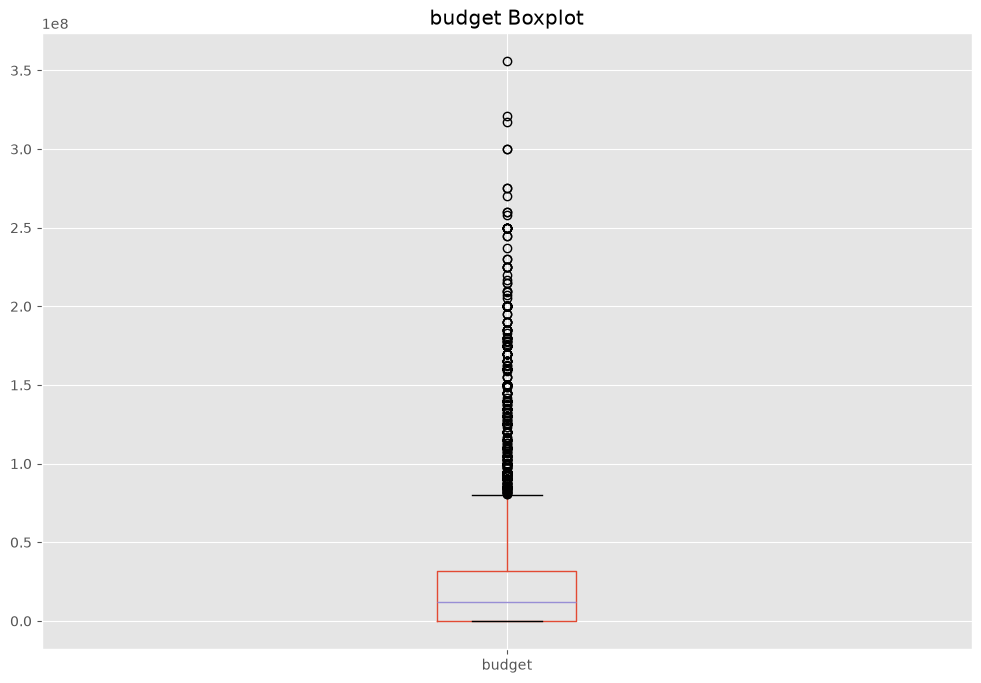

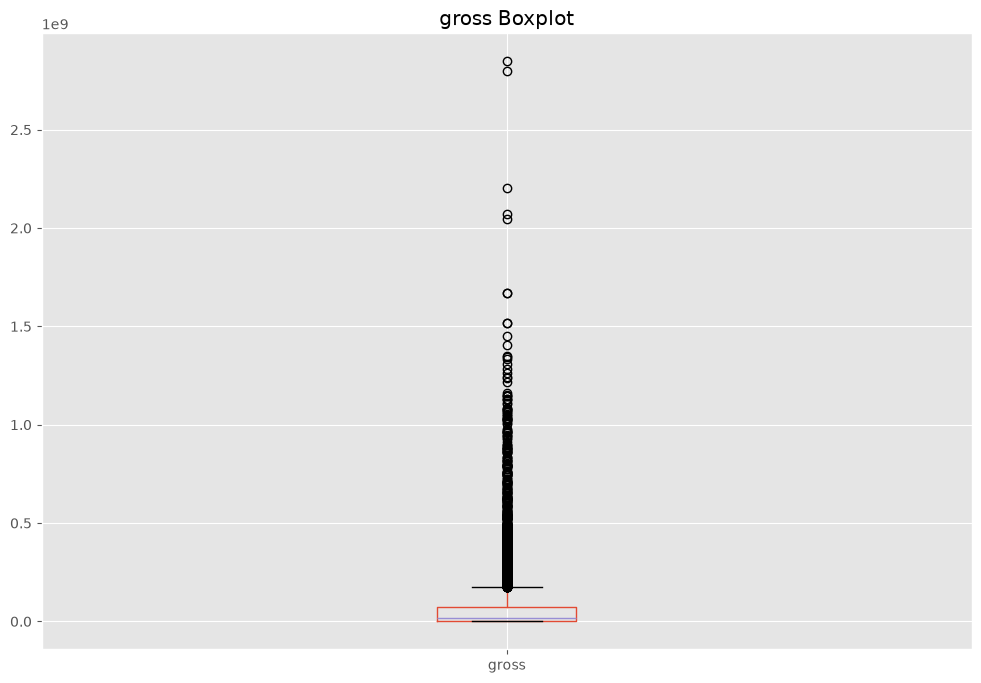

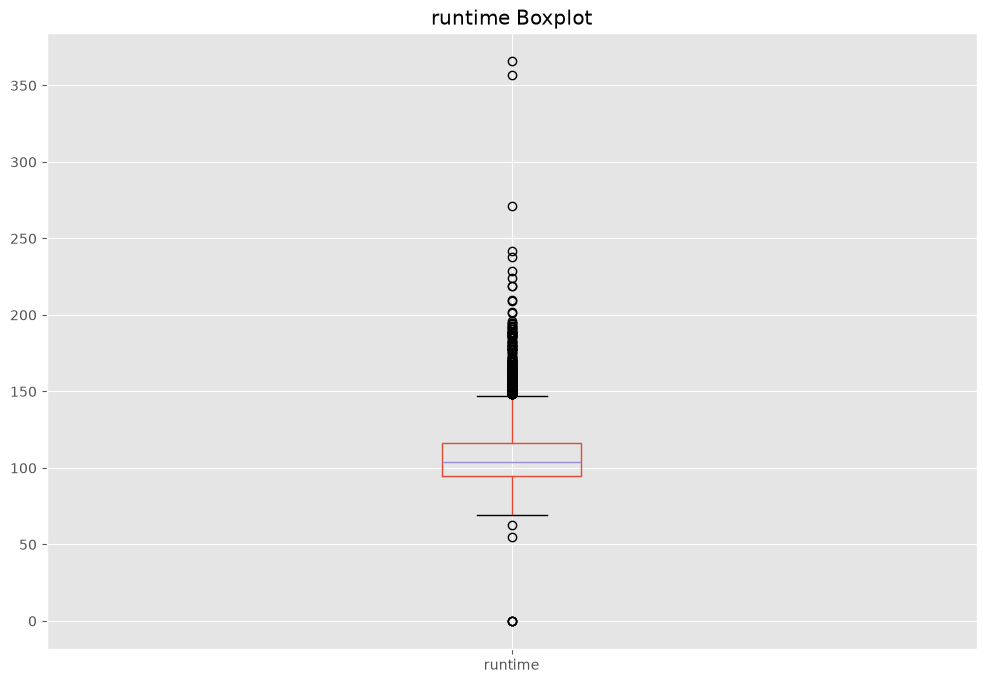

In [ ]:
# --- Outliers ---
# Checking Outliers
for col in df.columns:
    if is_numeric_dtype(df[col]):
        df.boxplot(column=[col])
        plt.title(rf'{col} Boxplot')
        plt.show()

# sns.boxplot(data=df)

<h1>Data Correlation</h1>

In [25]:
df.sort_values(by=['gross'], ascending=False)

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,releasedDate,yearCorrect,releasedCountry
5445,Avatar,PG-13,Action,2009,"December 18, 2009 (United States)",8,1100000,James Cameron,James Cameron,Sam Worthington,United States,237000000,2847246203,Twentieth Century Fox,162,2009-12-18,2009,United States
7445,Avengers: Endgame,PG-13,Action,2019,"April 26, 2019 (United States)",8,903000,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,356000000,2797501328,Marvel Studios,181,2019-04-26,2019,United States
3045,Titanic,PG-13,Drama,1997,"December 19, 1997 (United States)",8,1100000,James Cameron,James Cameron,Leonardo DiCaprio,United States,200000000,2201647264,Twentieth Century Fox,194,1997-12-19,1997,United States
6663,Star Wars: Episode VII - The Force Awakens,PG-13,Action,2015,"December 18, 2015 (United States)",8,876000,J.J. Abrams,Lawrence Kasdan,Daisy Ridley,United States,245000000,2069521700,Lucasfilm,138,2015-12-18,2015,United States
7244,Avengers: Infinity War,PG-13,Action,2018,"April 27, 2018 (United States)",8,897000,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,321000000,2048359754,Marvel Studios,149,2018-04-27,2018,United States
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7663,More to Life,NaN,Drama,2020,"October 23, 2020 (United States)",3,18,Joseph Ebanks,Joseph Ebanks,Shannon Bond,United States,7000,0,NaN,90,2020-10-23,2020,United States
641,Blame It on the Night,PG-13,Comedy,1984,"November 2, 1984 (United States)",5,172,Gene Taft,Gene Taft,Nick Mancuso,United States,0,0,Delphi II Productions,85,1984-11-02,1984,United States
7658,Black Wall Street Burning,R,Drama,2020,"February 7, 2020 (United States)",7,35,Marcus Brown,Dekoven Riggins,Dan Belcher,United States,5000,0,Notis Studio,78,2020-02-07,2020,United States
671,Flesh+Blood,R,Adventure,1985,"August 30, 1985 (United States)",7,17000,Paul Verhoeven,Gerard Soeteman,Rutger Hauer,Netherlands,6500000,0,Riverside Pictures,126,1985-08-30,1985,United States


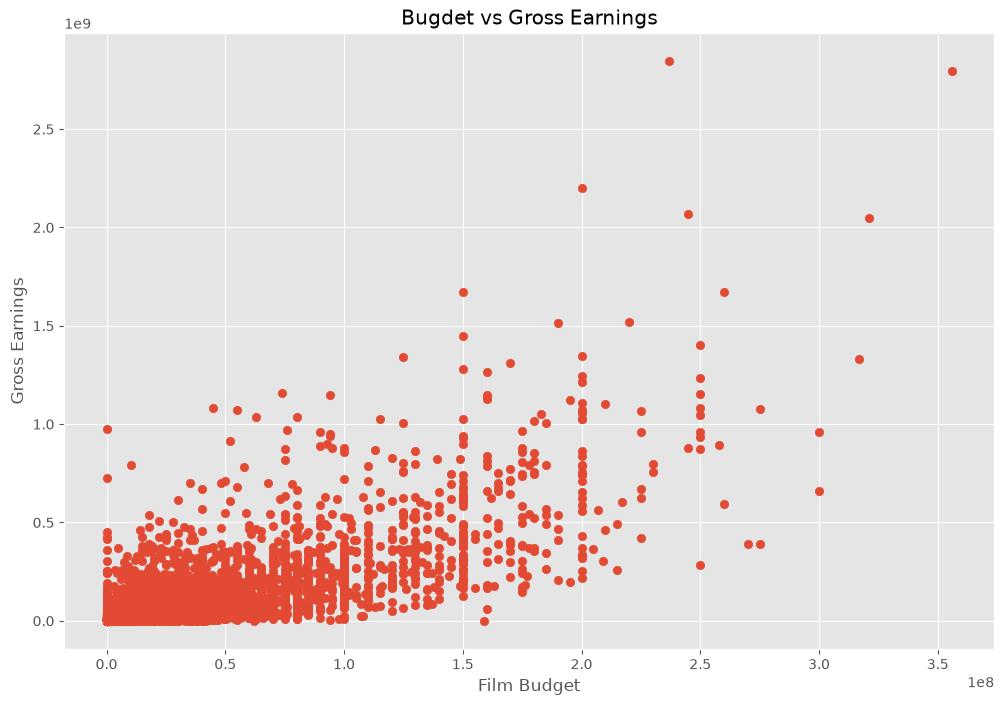

In [26]:
# Scatter plot Comparing Budget vs Gross
plt.scatter(x=df['budget'], y=df['gross'])
plt.title('Bugdet vs Gross Earnings')
plt.xlabel('Film Budget')
plt.ylabel('Gross Earnings')
plt.show()

<Axes: xlabel='budget', ylabel='gross'>

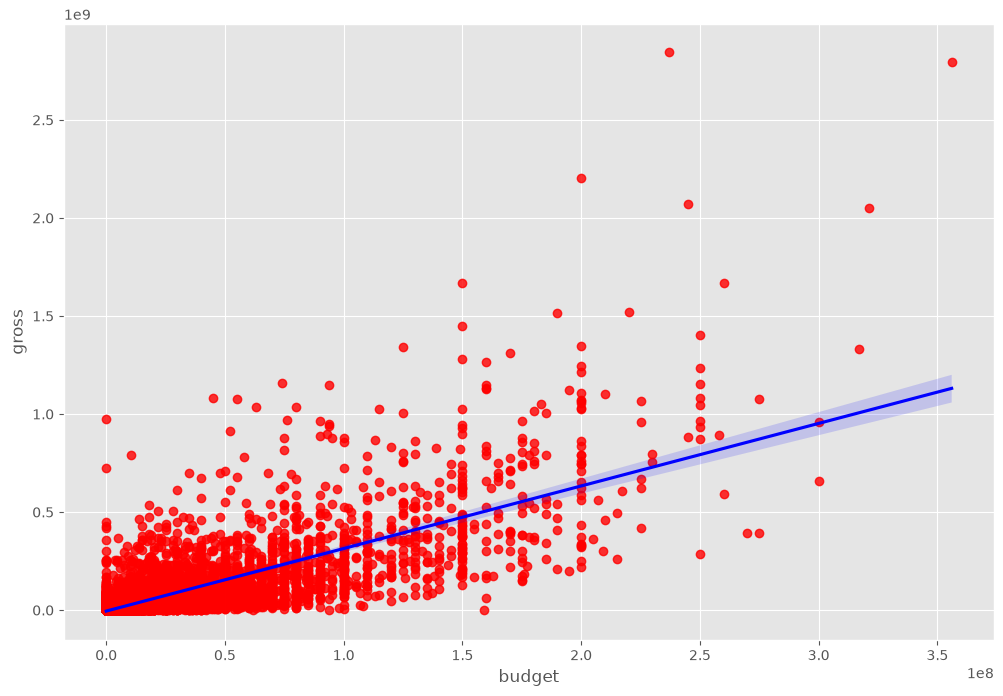

In [27]:
# Seaborn Plot Budget vs Gross
sns.regplot(x='budget', y='gross', data=df, scatter_kws={'color':'red'}, line_kws={'color':'blue'})

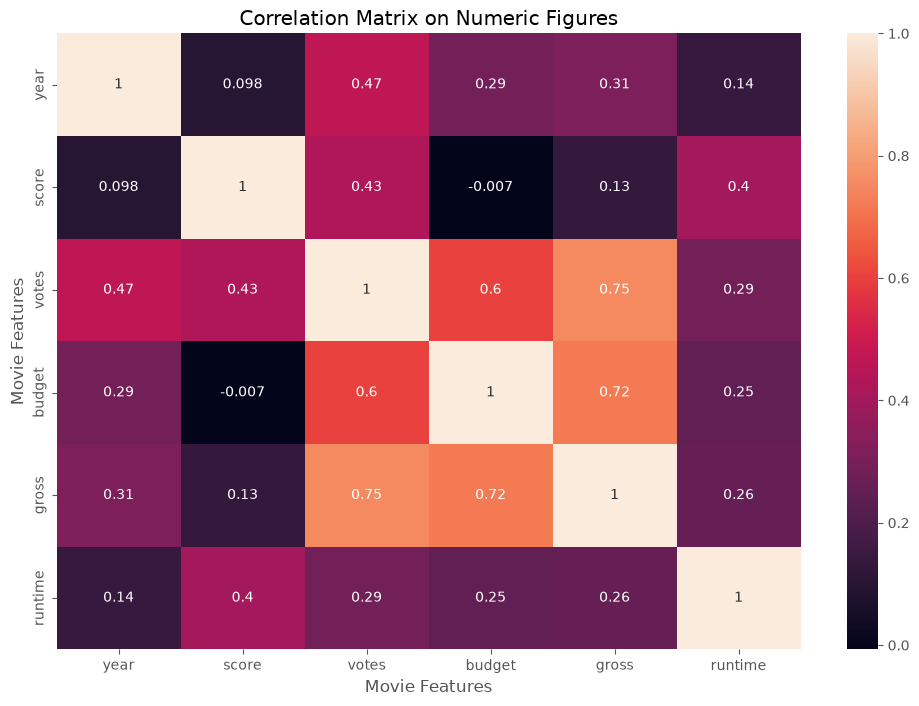

In [ ]:
# --- All Numeric Correlation ---
df.corr(numeric_only=True, method='spearman')

# Visualize Numeric Correlation
correlation_matrix = df.corr(numeric_only=True, method='spearman')
sns.heatmap(correlation_matrix, annot=True)
plt.title('Correlation Matrix on Numeric Figures')
plt.xlabel('Movie Features')
plt.ylabel('Movie Features')
plt.show()

,budget,gross,roiPercentage
company,,,
Marvel Studios,"200,000,000","1,184,074,374",411
Pixar Animation Studios,"147,500,000","605,657,396",397


Mann-whitney U test: Gross Earnings Marvel Studios vs Pixar Animation Studios:
U-statistic: 121.0
P-value: 0.005107905424995494

Gross vs Budget Correlation:
Marvel Studios: 0.908178238171182
Pixar Animation Studios: 0.16343118533964468


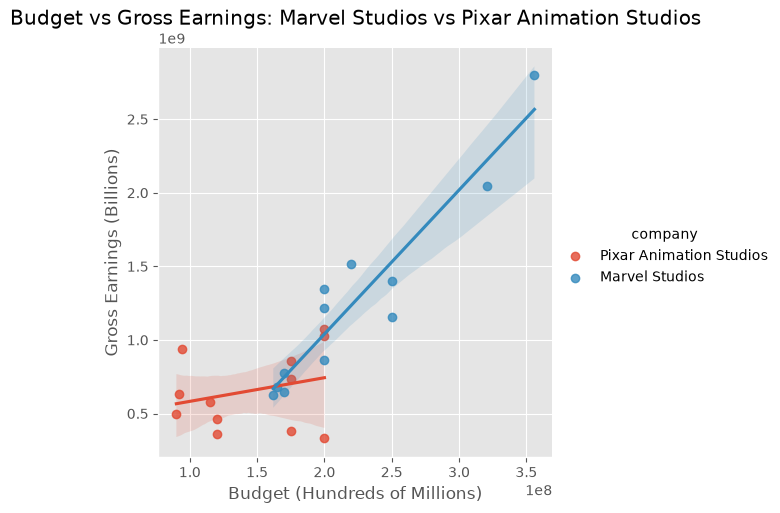

In [ ]:
# --- Comparing Groups ---
# Comparing between 2 Highest Gross Median Companies
# Filter Out Less than 10 Movies Companies
validDf = df[df['company'].isin(df['company'].value_counts()[df['company'].value_counts() >= 10].index)]

# Get Top 2 Highest Gross Median Companies
top2Gross = validDf.groupby('company')['gross'].median().sort_values(ascending=False).head(2).index.to_list()
comp1, comp2 = top2Gross[0], top2Gross[1]
top2Com = validDf[validDf['company'].isin(top2Gross)].copy()

top2Com['profit'] = top2Com['gross'] - top2Com['budget']    # True Profit = Gross / 2 - Budget * 2
top2Com['roiPercentage'] = (top2Com['profit'] / top2Com['budget']) * 100
topCom1 = top2Com[top2Com['company'] == comp1]
topCom2 = top2Com[top2Com['company'] == comp2]

summary = top2Com.groupby('company')[['budget', 'gross', 'roiPercentage']].median()
display(summary)

# t-test for even data | mann-whitney u test for skewed data 
# t_stat, p_value = stats.ttest_ind(MSGross, IEGross)
t_stat, p_value = mannwhitneyu(topCom1['gross'], topCom2['gross'])
print(f'Mann-whitney U test: Gross Earnings {comp1} vs {comp2}:\nU-statistic: {t_stat}\nP-value: {p_value}\n')

# Correlation
corr1 = topCom1['gross'].corr(topCom1['budget'], method='spearman')
corr2 = topCom2['gross'].corr(topCom2['budget'], method='spearman')
print('Gross vs Budget Correlation:')
print(f'{comp1}: {corr1}')
print(f'{comp2}: {corr2}')

# Visualization
sns.lmplot(x='budget', y='gross', hue='company', data=top2Com)

plt.title(f'Budget vs Gross Earnings: {comp1} vs {comp2}')
plt.xlabel('Budget (Hundreds of Millions)')
plt.ylabel('Gross Earnings (Billions)')
plt.show()

Kruskal Statistic: 29.152609828741618
P-value: 7.278730661932588e-06

Marvel Studios: 0.908178238171182
Pixar Animation Studios: 0.16343118533964468
Lucasfilm: 0.56535215562246
DreamWorks Animation: 0.48401064835295415
Walt Disney Animation Studios: 0.6650369038981687


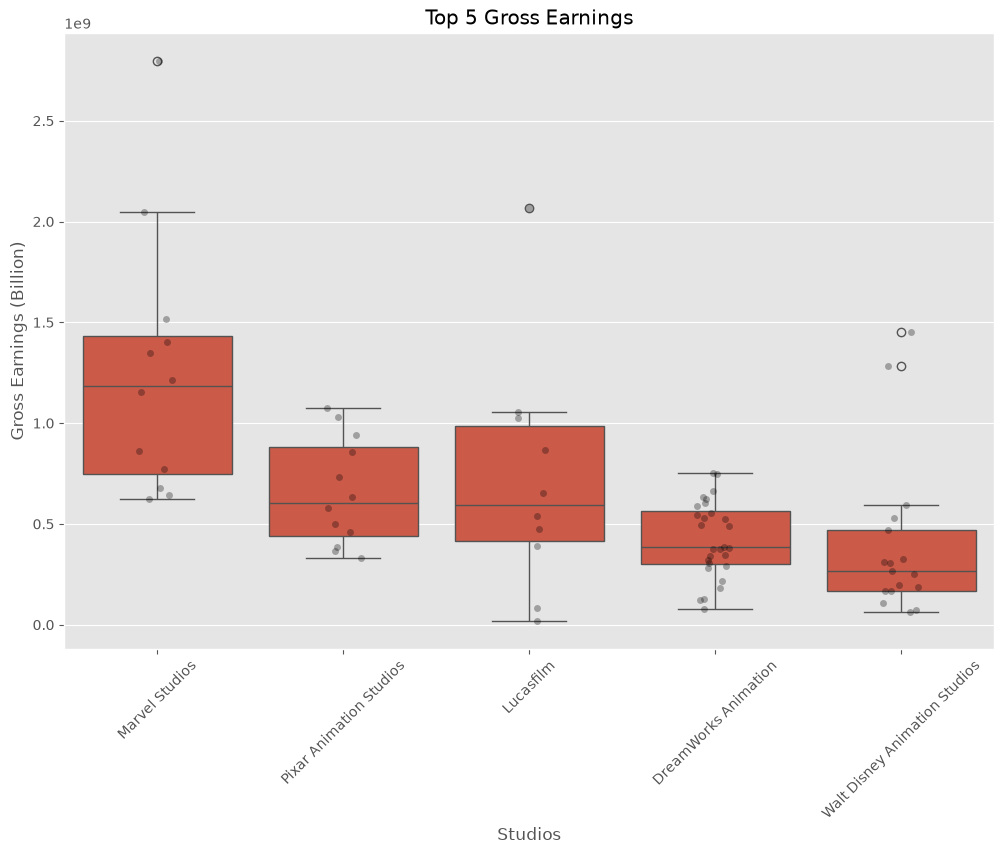

In [ ]:
# Comparting between 5 Highest Gross Median Companies
# Filter Out Less than 10 Movies Companies
validDf = df[df['company'].isin(df['company'].value_counts()[df['company'].value_counts() >= 10].index)]

# Get Top 5 Highest Gross Median Companies
top5ComName = validDf.groupby('company')['gross'].median().sort_values(ascending=False).head(5).index.to_list()
top5ComGross = {name: validDf[validDf['company'] == name]['gross'] for name in top5ComName}

# anova for normal and similar data | kruskal for skewed and varied data
stat, p_value = stats.kruskal(*top5ComGross.values())
print(f"Kruskal Statistic: {stat}\nP-value: {p_value}\n")

# Correlation
for name in top5ComName:
    compData = validDf[validDf['company'] == name]
    corr = compData['gross'].corr(compData['budget'], method='spearman')
    print(f'{name}: {corr}')
    
# Visualization
top5ComFull = validDf[validDf['company'].isin(top5ComName)]

sns.boxplot(x='company', y='gross', data=top5ComFull, order=top5ComName)
sns.stripplot(x='company', y='gross', data=top5ComFull, color='black', alpha=0.3, order=top5ComName)

plt.title('Top 5 Gross Earnings')
plt.xlabel('Studios')
plt.ylabel('Gross Earnings (Billion)')
plt.xticks(rotation=45)
plt.show() 